In [2]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm.auto import tqdm

df = pd.read_parquet("reddit_opinion_climate_change_cleaned_final.parquet")
device = 0 if torch.cuda.is_available() else -1

clf = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-base-zeroshot-v2.0",
               device=device, torch_dtype=torch.float16 if device == 0 else torch.float32)
labels = ["This text supports taking action on climate change", "This text is skeptical of climate change"]

c:\Users\bhatr\Documents\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
c:\Users\bhatr\Documents\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2101.15it/s]


In [3]:
texts = df["clean_text"].astype(str).str[:1000].tolist()

scores = []
results = clf((t for t in texts), candidate_labels=labels, hypothesis_template="{}", batch_size=32)
for r in tqdm(results, total=len(texts), desc="Stance scoring"):
    scores.append(dict(zip(r["labels"], r["scores"]))[labels[0]])

df["stance_score"] = scores
df.to_parquet("reddit_climate_stance_scored.parquet", index=False)

Stance scoring: 100%|██████████| 1894876/1894876 [3:48:28<00:00, 138.23it/s]  


In [ ]:
              # should say cuda:0

2.14.0+cu126
True


NameError: name 'clf' is not defined

In [ ]:
df = pd.read_parquet("reddit_climate_stance_scored.parquet")
df.groupby("subreddit")["stance_score"].agg(["mean", "count"]).sort_values("mean")

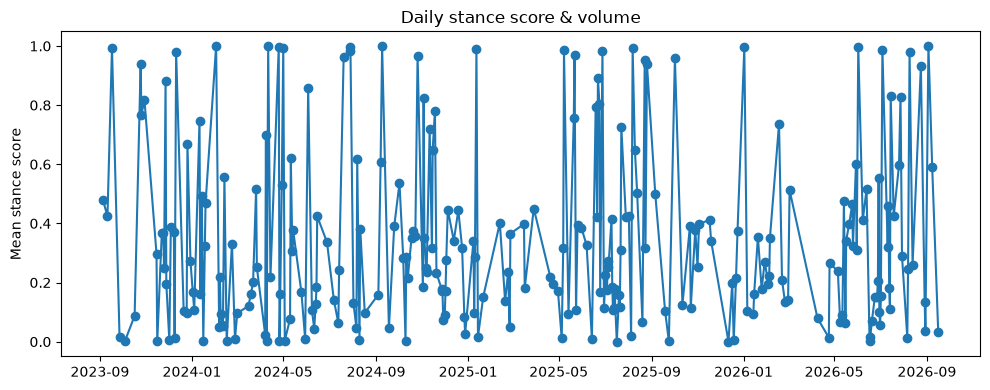

In [22]:
import matplotlib.pyplot as plt

df = df[df["created_time"] >= "2023-01-01"]

daily = df.groupby(df["created_time"].dt.date)["stance_score"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily.index, daily["mean"], marker="o")
ax.set_ylabel("Mean stance score")
plt.title("Daily stance score & volume")
plt.tight_layout()
plt.show()

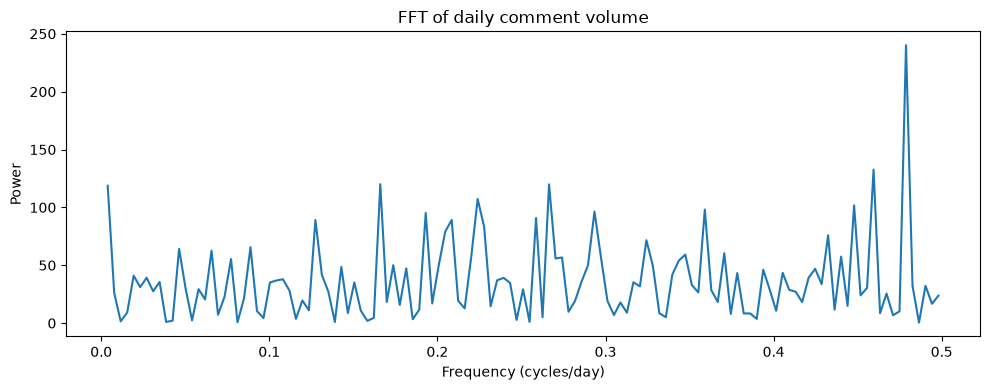

In [23]:
import numpy as np

# use volume (or swap for daily["mean"] to check stance periodicity)
signal = daily["count"].values
signal = signal - signal.mean()  # remove DC component

fft_vals = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(signal), d=1)  # d=1 day
    
power = np.abs(fft_vals) ** 2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs[1:], power[1:])  # skip freq=0
ax.set_xlabel("Frequency (cycles/day)")
ax.set_ylabel("Power")
plt.title("FFT of daily comment volume")
plt.tight_layout()
plt.show()

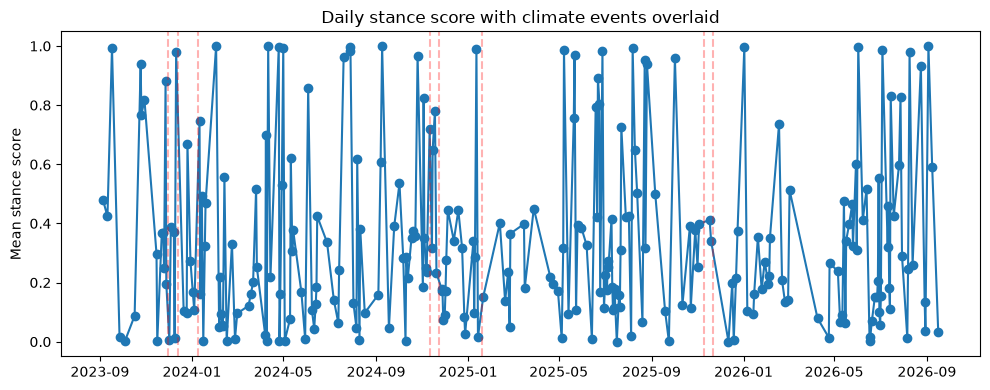

In [24]:
import matplotlib.pyplot as plt

events = pd.read_csv("climate_events.csv", parse_dates=["date"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily.index, daily["mean"], marker="o")

for d in events["date"]:
    if d.date() >= daily.index.min() and d.date() <= daily.index.max():
        ax.axvline(d, color="red", alpha=0.3, linestyle="--")

ax.set_ylabel("Mean stance score")
plt.title("Daily stance score with climate events overlaid")
plt.tight_layout()
plt.show()